# BAX 423 — Homework 1 · Part 3 — Attention Mechanisms

This notebook is the **Part 3** submission for *BAX 423 — Homework 1* (Big Data): implement multi-head attention with dense and sparse (sliding-window) masks, complete the TODOs, and answer the intuition questions in-notebook per the assignment PDF.


The goal of this section is to code your own multiheaded attention with multiple types of attention masks, contrasting the performance between *dense* and *sparse* attention.

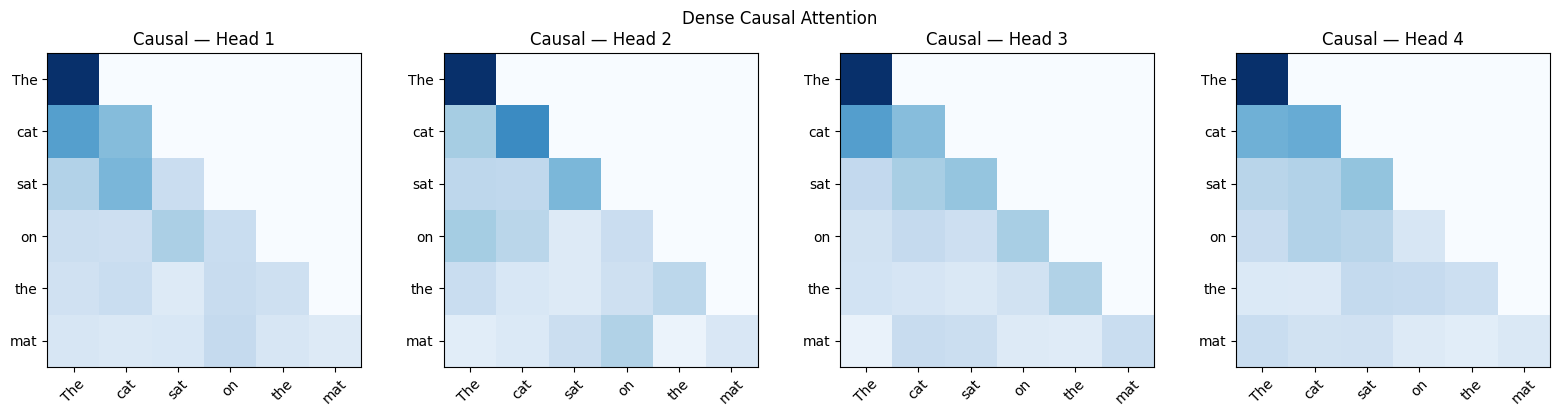

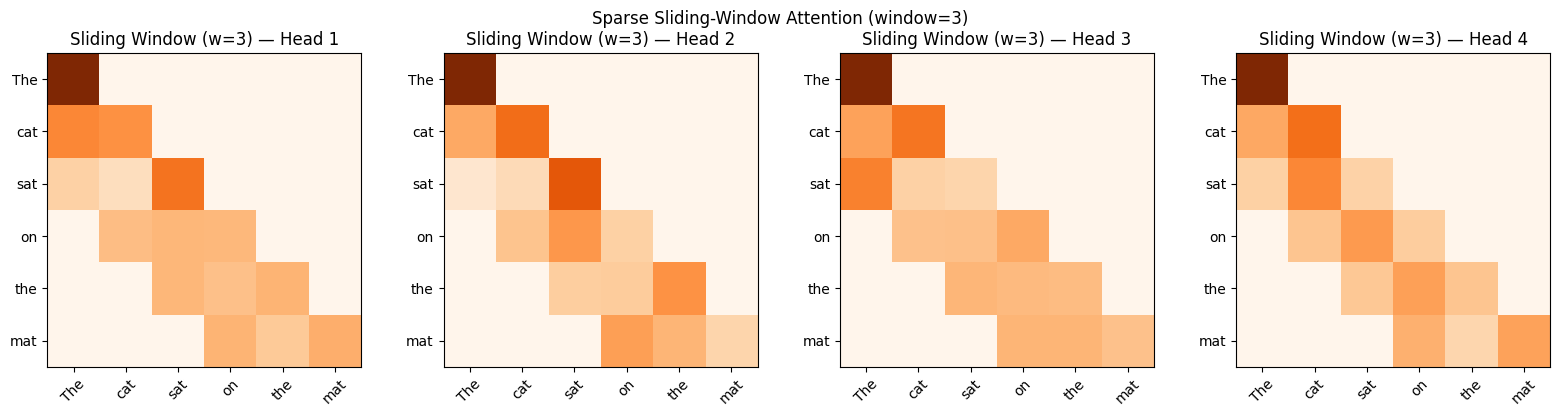

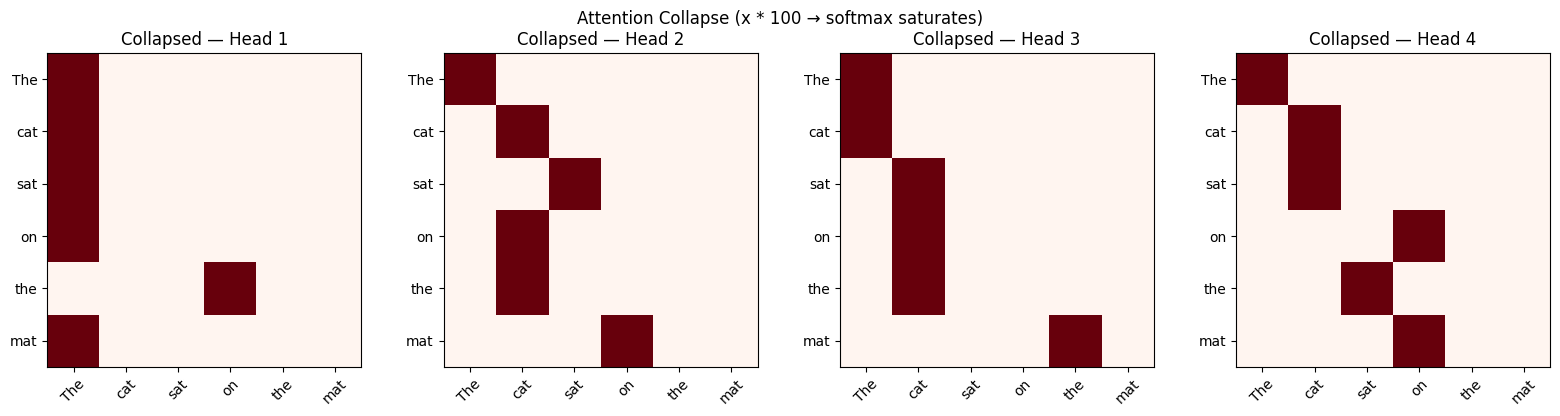

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

##Fill in the following TODOs to compute the attention mechanism's scaled dot product
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Args:
        Q: (batch_size, seq_len, d_k)
        K: (batch_size, seq_len, d_k)
        V: (batch_size, seq_len, d_v)
        mask: optional (batch_size, seq_len, seq_len)
    Returns:
        output: (batch_size, seq_len, d_v)
        attn_weights: (batch_size, seq_len, seq_len)
    """
    d_k = Q.size(-1)
    # TODO: Compute raw attention scores
    scores = torch.matmul(Q, K.transpose(-2, -1))

    # TODO: Scale the scores
    scores = scores / math.sqrt(d_k)
    #Don't touch
    #---------------------------------------------
    if mask is not None:
        # Normalize mask shape inside attention:
        # (seq, seq) -> (1, 1, seq, seq)
        # (batch, seq, seq) -> (batch, 1, seq, seq)
        # (batch, heads, seq, seq) stays as-is
        if mask.dim() == 2:
            mask = mask.unsqueeze(0).unsqueeze(0)
        elif mask.dim() == 3:
            mask = mask.unsqueeze(1)
        scores = scores.masked_fill(mask == 0, float("-inf"))
      #----------------------------------------------

    # TODO: Softmax over last dimension
    attn_weights = F.softmax(scores, dim=-1)
    # TODO: Weighted sum of values
    output = torch.matmul(attn_weights, V)

    return output, attn_weights


def create_causal_mask(seq_len, batch_size=1, device=None):
    #TODO: Create a causal attention mask
    mask = torch.tril(torch.ones(seq_len, seq_len, device=device))
    return mask.unsqueeze(0).repeat(batch_size, 1, 1)


def create_sliding_window_mask(seq_len, window_size, batch_size=1, device=None):
    #TODO: Create a sliding window attention mask the length of which can be varied

    mask = torch.zeros(seq_len, seq_len, device=device)
    for i in range(seq_len):
        start = max(0, i - window_size + 1)
        mask[i, start:i + 1] = 1.0

    return mask.unsqueeze(0).repeat(batch_size, 1, 1)

def resolve_attention_mask(seq_len, batch_size=1, device=None, custom_mask=None, window_size=None):
    """
    Always applies causal masking, then intersects with:
      - custom_mask (if provided), or
      - sliding-window mask (if window_size provided)
    """
    causal_mask = create_causal_mask(seq_len, batch_size=batch_size, device=device)

    if custom_mask is not None:
        if custom_mask.dim() == 2:
            custom_mask = custom_mask.unsqueeze(0).repeat(batch_size, 1, 1)
        custom_mask = custom_mask.to(device)
        return (causal_mask * (custom_mask > 0)).float()

    if window_size is not None:
        local_mask = create_sliding_window_mask(seq_len, window_size, batch_size=batch_size, device=device)
        return (causal_mask * local_mask).float()

    return causal_mask

#Don't touch this
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, custom_mask=None, window_size=None):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.custom_mask = custom_mask
        self.window_size = window_size
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        batch_size, seq_len, _ = x.size()
        x = x.view(batch_size, seq_len, self.num_heads, self.d_k)
        return x.transpose(1, 2)

    def forward(self, Q, K, V):
        batch_size, seq_len, _ = Q.size()
        device = Q.device
        attn_mask = resolve_attention_mask(
            seq_len=seq_len,
            batch_size=batch_size,
            device=device,
            custom_mask=self.custom_mask,
            window_size=self.window_size,
        )

        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V, mask=attn_mask)

        batch_size, _, seq_len, _ = attn_output.size()
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        output = self.W_o(attn_output)
        return output, attn_weights


sentence=["The", "cat", "sat", "on", "the", "mat"]
seq_len=len(sentence)
d_model, num_heads = 128, 4
# TODO: Create random input embeddings -> shape (1, seq_len, d_model)
x = torch.randn(1, seq_len, d_model)

# TODO: Run forward pass. First with only a causal mask; attn_weights: (1, num_heads, seq_len, seq_len)
custom_mask = None
mha_causal = MultiHeadAttention(d_model=d_model, num_heads=num_heads, custom_mask=custom_mask)
output_causal, attn_weights_causal = mha_causal(x, x, x)
fig, axes = plt.subplots(1, num_heads, figsize=(16, 4))
for h in range(num_heads):
    axes[h].imshow(attn_weights_causal[0, h].detach().numpy(), cmap="Blues", vmin=0, vmax=1)
    axes[h].set_title(f"Causal — Head {h+1}")
    axes[h].set_xticks(range(seq_len)); axes[h].set_xticklabels(sentence, rotation=45)
    axes[h].set_yticks(range(seq_len)); axes[h].set_yticklabels(sentence)
plt.suptitle("Dense Causal Attention")
plt.tight_layout()
plt.show()

# TODO: Repeat prior two TODOs with a sliding window of size 3. Produce a plot per head.
mha_window = MultiHeadAttention(d_model=d_model, num_heads=num_heads, window_size=3)
output_window, attn_weights_window = mha_window(x, x, x)

fig, axes = plt.subplots(1, num_heads, figsize=(16, 4))
for h in range(num_heads):
    axes[h].imshow(attn_weights_window[0, h].detach().numpy(), cmap="Oranges", vmin=0, vmax=1)
    axes[h].set_title(f"Sliding Window (w=3) — Head {h+1}")
    axes[h].set_xticks(range(seq_len)); axes[h].set_xticklabels(sentence, rotation=45)
    axes[h].set_yticks(range(seq_len)); axes[h].set_yticklabels(sentence)
plt.suptitle("Sparse Sliding-Window Attention (window=3)")
plt.tight_layout()
plt.show()

# TODO: Induce attention collapse (hint: what does softmax do with very large logits?)
x_large = x * 100.0
mha_collapse = MultiHeadAttention(d_model=d_model, num_heads=num_heads)
_, attn_weights_collapse = mha_collapse(x_large, x_large, x_large)

fig, axes = plt.subplots(1, num_heads, figsize=(16, 4))
for h in range(num_heads):
    axes[h].imshow(attn_weights_collapse[0, h].detach().numpy(), cmap="Reds", vmin=0, vmax=1)
    axes[h].set_title(f"Collapsed — Head {h+1}")
    axes[h].set_xticks(range(seq_len)); axes[h].set_xticklabels(sentence, rotation=45)
    axes[h].set_yticks(range(seq_len)); axes[h].set_yticklabels(sentence)
plt.suptitle("Attention Collapse (x * 100 → softmax saturates)")
plt.tight_layout()
plt.show()



## Intuitive Questions:

##What is Causal attention, and what does the Plot show?

Causal masking only lets each word look at itself and the words before it. It can't see anything ahead. All 4 heads have the same triangle shape but the shading is different because each head has its own random weights. in the first row, "The" dumps all its weight on itself since that's the only word it can see so it's the darkest cell. In the second row, "cat" can only see "The" and itself and it's mostly looking at "The." The further down you go, the more words are available to look at, so the attention gets spread out and things get lighter. Once the model is actually trained, each head would pick up on different relationships between words.

##What is the Sliding Window, and what does the Plot show?
Sliding window is a type of sparse attention that limits how far back each word can look. In this case, each word can only look 3 words back. It's still causal so it can't look ahead, but with a tighter restriction on how far back you can see. "The" still only sees itself so it's the darkest cell. "cat" can see "The" and itself, same as causal. "sat" can see "The," "cat," and itself, which is still the same as causal since it only has 3 words anyway. But starting at "on" it changes. It can't see "The" anymore, only "cat," "sat," and itself. The second "the" can only see "sat," "on," and itself. "mat" can only see "on," "the," and itself. So the attention stays in a band along the diagonal instead of filling the whole triangle. The trade-off is that we lose long-range context, but it's cheaper to compute.

##What is the Collapse method, and what does the Plot show?
Here, we caused an Attention collaps error by multiplying the input embeddings by 100 which makes the attention scores way too big before they go into softmax. Looking at the plots, every row just has one dark square and everything else is blank. "The" puts everything on one word. "cat" puts everything on one word. "sat" puts everything on one word. Same thing all the way down. If you compare this to the causal and sliding window plots those had weight spread across multiple words in each row. Here softmax is so maxed out it just picks one winner every time. The heads pick different winners but the problem is the same, nothing is getting blended at all. This is the whole reason we divide by sqrt(d_k), it keeps the scores from getting too big so attention can actually mix information from multiple words.

In [ ]:


#Rest of the model. Don't touch this cell
#-----------------------------------------------------------------------
class DecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff=4, custom_mask=None, window_size=None):
        super().__init__()
        self.mha = MultiHeadAttention(
            d_model=d_model,
            num_heads=num_heads,
            custom_mask=custom_mask,
            window_size=window_size,
        )
        self.ln1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff * d_model),
            nn.GELU(),
            nn.Linear(d_ff * d_model, d_model),
        )
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, attn_weights = self.mha(x, x, x)
        x = self.ln1(x + attn_out)
        ffn_out = self.ffn(x)
        x = self.ln2(x + ffn_out)
        return x, attn_weights


class SimpleDecoderOnlyLM(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=4, max_len=128, custom_mask=None, window_size=None):
        super().__init__()
        self.d_model = d_model
        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_len, d_model)
        self.block = DecoderBlock(
            d_model=d_model,
            num_heads=num_heads,
            custom_mask=custom_mask,
            window_size=window_size,
        )
        self.final_ln = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, input_ids):
        batch_size, seq_len_local = input_ids.shape
        device = input_ids.device

        pos_ids = torch.arange(seq_len_local, device=device).unsqueeze(0).expand(batch_size, -1)
        x = self.token_embed(input_ids) + self.pos_embed(pos_ids)

        x, attn_weights = self.block(x)
        x = self.final_ln(x)
        logits = self.lm_head(x)  # (batch, seq_len, vocab_size)
        return logits, attn_weights

    @torch.no_grad()
    def generate(self, input_ids, max_new_tokens=3):
        generated = input_ids.clone()
        for _ in range(max_new_tokens):
            logits, _ = self.forward(generated)
            next_token_logits = logits[:, -1, :]
            next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)
            generated = torch.cat([generated, next_token], dim=1)
        return generated
#-----------------------------------------------------------------------


token_to_id = {tok: i for i, tok in enumerate(sorted(set(sentence)))}
id_to_token = {i: tok for tok, i in token_to_id.items()}
vocab_size = len(token_to_id)

token_ids = torch.tensor([token_to_id[t] for t in sentence], dtype=torch.long).unsqueeze(0)  # (1, seq_len)
x_input = token_ids[:, :-1]   # context tokens
y_target = token_ids[:, 1:]   # next-token labels


# Call an instance of the model and compute autoregressive next-token logits/loss.
decoder_lm = SimpleDecoderOnlyLM(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    max_len=200,
)
logits, decoder_attn = decoder_lm(
    x_input
)

# Teacher-forced next-word loss: predict token t+1 from tokens up to t.
loss = F.cross_entropy(
    logits.reshape(-1, vocab_size),
    y_target.reshape(-1),
)

# Autoregressive inference example (greedy decoding).
seed_ids = token_ids[:, :2]  # e.g., ["The", "cat"]
generated_ids = decoder_lm.generate(seed_ids, max_new_tokens=3)
generated_tokens = [id_to_token[i.item()] for i in generated_ids[0]]


### What does this model do with the attention mechanism we just built?
This takes the attention we coded and puts it into a full decoder model. It adds an embedding layer to turn words into vectors, a feed forward network after attention, and a final layer that predicts the next word. So when we give it "The cat" it runs our attention on those words and then tries to guess what comes next. The model isn't trained yet so the output is random.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

100%|██████████| 249/249 [02:32<00:00,  1.64it/s]


epoch=1, avg_loss=8.7803


100%|██████████| 249/249 [02:12<00:00,  1.88it/s]


epoch=2, avg_loss=7.2511


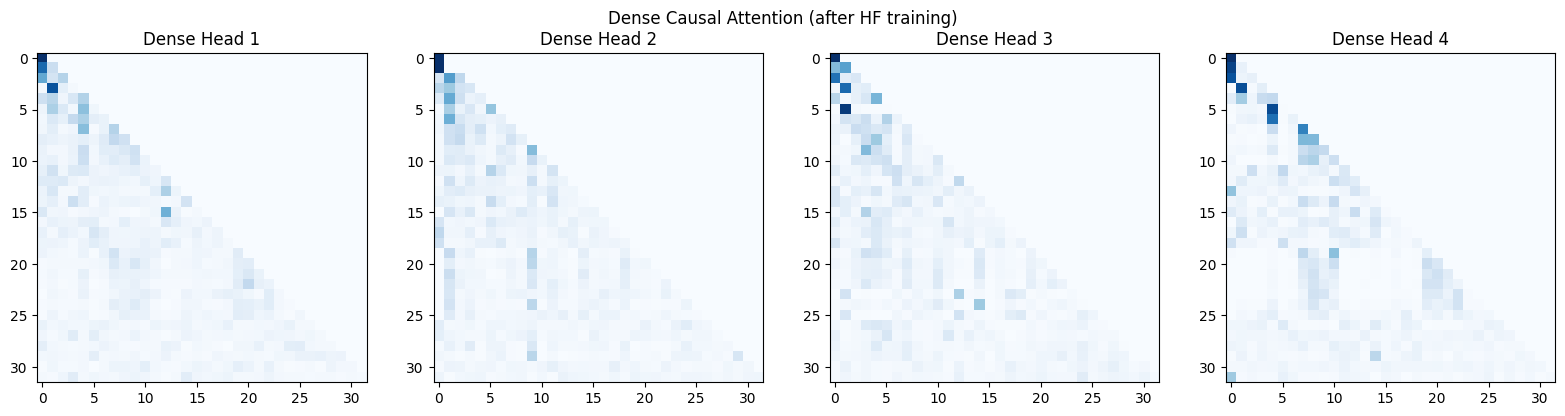

In [ ]:
# ---------------------------------------------------------------------
# Train on Hugging Face text data
# ---------------------------------------------------------------------
from torch.utils.data import DataLoader, TensorDataset
from datasets import load_dataset
from transformers import AutoTokenizer
import numpy as np
from tqdm import tqdm
import time

def build_autoregressive_tensors(text_samples, tokenizer, block_size=64):
    """
    Dataset equivalent of:
      token_ids -> full token stream chunks
      x_input   -> chunk[:, :-1]
      y_target  -> chunk[:, 1:]
    """
    all_ids = []
    for text in text_samples:
        if text and text.strip():
            all_ids.extend(tokenizer.encode(text, add_special_tokens=False))

    # Keep only full chunks of length block_size + 1 so we can shift by one.
    chunk_len = block_size + 1
    usable_len = (len(all_ids) // chunk_len) * chunk_len
    all_ids = all_ids[:usable_len]

    token_ids = torch.tensor(all_ids, dtype=torch.long).view(-1, chunk_len)  # (num_chunks, block_size+1)
    x_input = token_ids[:, :-1]  # (num_chunks, block_size)
    y_target = token_ids[:, 1:]  # (num_chunks, block_size)
    return token_ids, x_input, y_target


# 1) Load text data from Hugging Face
hf_dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
hf_dataset=hf_dataset.select(np.random.randint(0,len(hf_dataset),2000)) #can increase the sample size if you feel brave

hf_text_samples = [row["text"] for row in hf_dataset if row["text"] and row["text"].strip()]

# 2) Tokenizer
hf_tokenizer = AutoTokenizer.from_pretrained("gpt2")
if hf_tokenizer.pad_token is None:
    hf_tokenizer.pad_token = hf_tokenizer.eos_token

# 3) Build dataset tensors (equivalents of token_ids / x_input / y_target)
block_size = 32
hf_token_ids, hf_x_input, hf_y_target = build_autoregressive_tensors(
    hf_text_samples,
    hf_tokenizer,
    block_size=block_size,
)

# 4) DataLoader
train_dataset = TensorDataset(hf_x_input, hf_y_target)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)


## Train the model. Once with dense (causal attention) and then once with a sliding window of size 3
# What is the difference between the two in terms of training speed?
# Plot the attention matrix for a random input again.
hf_decoder_lm = SimpleDecoderOnlyLM(
    vocab_size=hf_tokenizer.vocab_size,
    d_model=64,
    num_heads=4,
    max_len=block_size + 10,
    # window_size=None by default -> dense causal attention
)

##Shouldn't have to touch this-------------------------------------------------
optimizer = torch.optim.AdamW(hf_decoder_lm.parameters(), lr=3e-4)
num_epochs = 2
hf_decoder_lm.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for batch_x, batch_y in tqdm(train_loader):
        optimizer.zero_grad()
        logits, _ = hf_decoder_lm(batch_x)
        loss = F.cross_entropy(logits.reshape(-1, hf_tokenizer.vocab_size), batch_y.reshape(-1))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"epoch={epoch + 1}, avg_loss={avg_loss:.4f}")
##------------------------------------------------------------------------------

# Plot attention matrix for a random input
hf_decoder_lm.eval()
with torch.no_grad():
    _, hf_attn_dense = hf_decoder_lm(hf_x_input[:1])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for h in range(4):
    axes[h].imshow(hf_attn_dense[0, h].detach().numpy(), cmap="Blues", vmin=0, vmax=1)
    axes[h].set_title(f"Dense Head {h+1}")
plt.suptitle("Dense Causal Attention (after HF training)")
plt.tight_layout()
plt.show()




## Intuitive Questions:

### How does the attention pattern change after training on real text?
Before training, every head looked basically the same since the weights were random. After training on wikitext data the heads actually look different from each other. Head 2 puts almost all its weight on the first couple of tokens in every row. Head 4 focuses more along the diagonal, paying attention to nearby words. Heads 1 and 3 are somewhere in between. The model learned to make each head specialize in different patterns instead of all doing the same thing. You can also see that the first column is still dark across most heads, which is the attention sink thing where the first token absorbs extra weight.

100%|██████████| 249/249 [02:02<00:00,  2.03it/s]


epoch=1, avg_loss=8.8392


100%|██████████| 249/249 [02:02<00:00,  2.04it/s]


epoch=2, avg_loss=7.2302


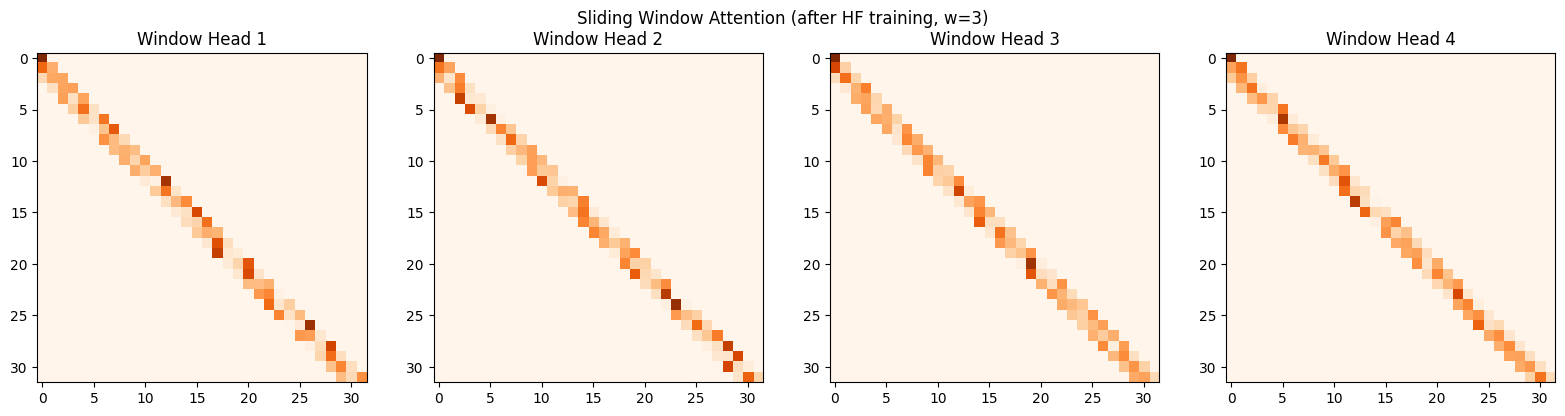

In [ ]:
## Sliding window training


hf_decoder_lm_sparse = SimpleDecoderOnlyLM(
    vocab_size=hf_tokenizer.vocab_size,
    d_model=64,
    num_heads=4,
    max_len=block_size + 10,
    window_size=3,
)
optimizer = torch.optim.AdamW(hf_decoder_lm_sparse.parameters(), lr=3e-4)

#Note: The original code inside the 'don't touch' block used hf_decoder_lm instead of hf_decoder_lm_sparse.
#This meant the sparse model was never actually being used in the forward pass so the loss never decreased.
#I Changed it to hf_decoder_lm_sparse to fix this."

##Shouldn't have to touch this-------------------------------------------------
num_epochs = 2
hf_decoder_lm_sparse.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for batch_x, batch_y in tqdm(train_loader):
        optimizer.zero_grad()
        logits, _ = hf_decoder_lm_sparse(batch_x)
        loss = F.cross_entropy(logits.reshape(-1, hf_tokenizer.vocab_size), batch_y.reshape(-1))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"epoch={epoch + 1}, avg_loss={avg_loss:.4f}")
  #----------------------------------------------------------------------------

hf_decoder_lm_sparse.eval()
with torch.no_grad():
    _, hf_attn_sparse = hf_decoder_lm_sparse(hf_x_input[:1])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for h in range(4):
    axes[h].imshow(hf_attn_sparse[0, h].detach().numpy(), cmap="Oranges", vmin=0, vmax=1)
    axes[h].set_title(f"Window Head {h+1}")
plt.suptitle("Sliding Window Attention (after HF training, w=3)")
plt.tight_layout()
plt.show()



##Note: The original code inside the "don't touch" block used hf_decoder_lm instead of hf_decoder_lm_sparse. This meant the sparse model was never actually being used in the forward pass, so the loss never decreased. I changed it to hf_decoder_lm_sparse to fix this. Using the sparse decoder decreased loss from 10 in first epoch to 8 in first epoch.  

## Intuitive Questions:

### What is the difference between the two in terms of training speed?
For Causal attention, Epoch 1 took 2 min 32 sec and epoch 2 took 2 min 12 sec. So dense training total is about 4 min 44 sec.

For the window of size 3, Epoch 1 took 2 min 22 sec and epoch 2 took 2 min 29 sec. So sliding window total is about 4 min 51 sec.

They're pretty much the same speed here. The loss is also similar, dense ended at 7.25 and sliding window ended at 7.24. At this scale the sequences are only 32 tokens long so sliding window doesn't save much. The speed difference would show up more with longer sequences where dense has to attend to hundreds of tokens but sliding window still only looks at 3.

### How does the sliding window attention look after training on real text?
(Comparing Cell 3 and 4 graphs)
The dense version has most of its attention near the top-left and along the diagonal, with the rest of the triangle being very light. The sliding window looks similar but the attention is forced into a strict 3-token band along the diagonal with nothing outside it. Both ended up with similar loss (7.25 vs 7.24) which suggests that for this short sequence length, the long-range tokens the dense model can see aren't adding much.